In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 50    # sweeps
SEED = 0    # dynamics RNG

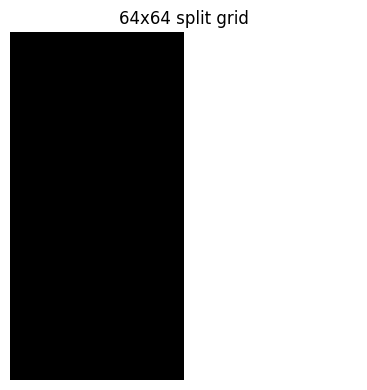

In [3]:
def make_split(size=64):
    """Left half 0 (black), right half 1 (white). Vertical boundary in the middle."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(64)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title("64x64 split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

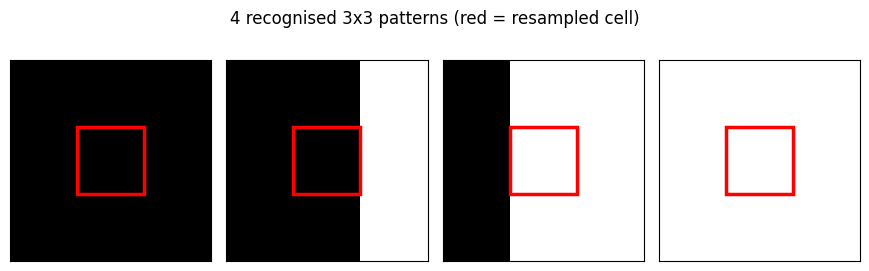

In [4]:
def win_key(w):
    """All nine cells of a 3x3 window, row-major."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """The set of complete 3x3 patterns that occur in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def plot_windows(seen):
    items = sorted(seen)
    fig, axes = plt.subplots(1, len(items), figsize=(2.2 * len(items), 2.8))
    axes = np.atleast_1d(axes)
    for ax, w in zip(axes, items):
        ax.imshow(np.array(w, dtype=float).reshape(3, 3), cmap="gray", vmin=0, vmax=1)
        ax.add_patch(plt.Rectangle((0.5, 0.5), 1, 1, fill=False,
                                   edgecolor="red", lw=2.5))
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{len(items)} recognised 3x3 patterns (red = resampled cell)")
    plt.tight_layout()
    plt.show()


seen = build_windows(grid)
plot_windows(seen)

In [5]:
def step_seq(field, seen, rng):
    """Sequential sweep, sites in random order. For each cell, try both centre
    values; keep whichever make the whole 3x3 a recognised pattern.
    Both work -> coin flip. Neither works -> leave the cell alone."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    unresolved = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2].copy()
        ok = []
        for v in (0, 1):
            w[1, 1] = v
            if win_key(w) in seen:
                ok.append(v)
        if len(ok) == 1:
            field[r, c] = ok[0]
        elif len(ok) == 2:
            field[r, c] = int(rng.random() < 0.5)
        else:
            unresolved += 1
    return field, unresolved


def run(field, seen, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. `field` itself is never modified.
    Prints only when the numbers change."""
    rng = np.random.default_rng(seed)
    original = field.copy()
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, unresolved = step_seq(f, seen, rng)
        state = (int((f != original).sum()), unresolved)
        if verbose and state != prev:
            print(f"  sweep {t:5d}: differing = {state[0]:5d}   unresolved = {state[1]}")
            prev = state
    return f

In [6]:
final_clean = run(grid, seen, verbose=False)
print("fixed point:", np.array_equal(final_clean, grid))

fixed point: True


Noise 10.00%, unrecognised windows left alone:
  sweep     1: differing =   155   unresolved = 1718
  sweep     2: differing =   155   unresolved = 1221


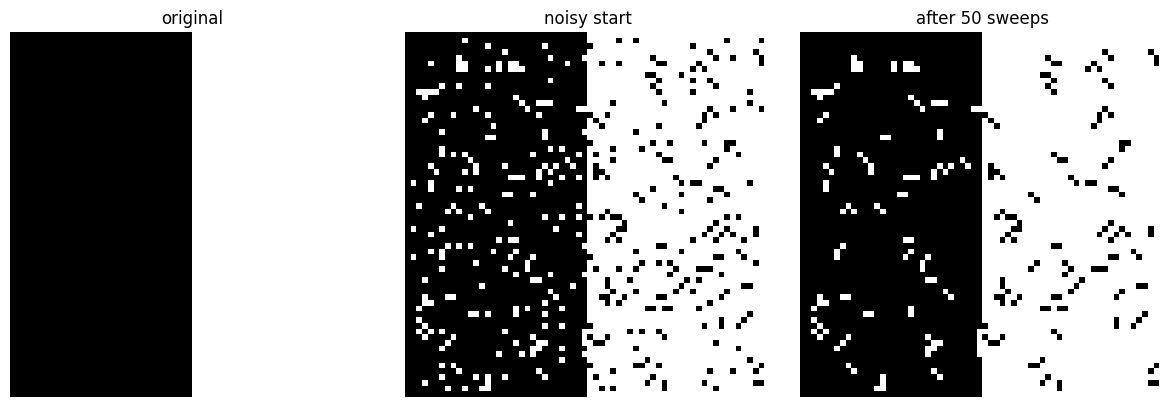

In [7]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


FRAC = 0.1
NOISE_SEED = 1

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
print(f"Noise {FRAC:.2%}, unrecognised windows left alone:")
final_noisy = run(noisy, seen)
plot_three(grid, noisy, final_noisy, N)

So how this code works is we add a fair bit of noise in this case, and we sweep one by one. We look at every single point, and we check its neighbors, and we flip until we find a pattern we recognize. If we never recognize the pattern, it doesn't change. The flaw we have here is we do not consider side neighbors, and so as we can see, chunks or noise particles that are connected by over Two to three to four pieces do not change, and you can actually guess what ones they're going to be. So a fix I could do here is maybe flip all 8 until we recognize the pattern. I'm not sure how plausible that is.Something we could try is to look at the grid, see which one of our recognized patterns it is close to, and then change it to that.  

Here I have gone with the nearest pattern repair method. 

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
N =1000 
SEED = 0     # RNG for sweep order
size = 64# grid size

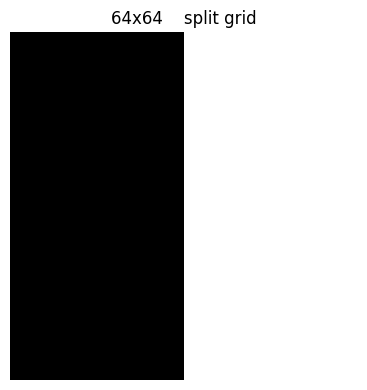

In [10]:
def make_split(size):
    """Left half black (0), right half white (1). One vertical boundary."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(size)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{size}x{size}    split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

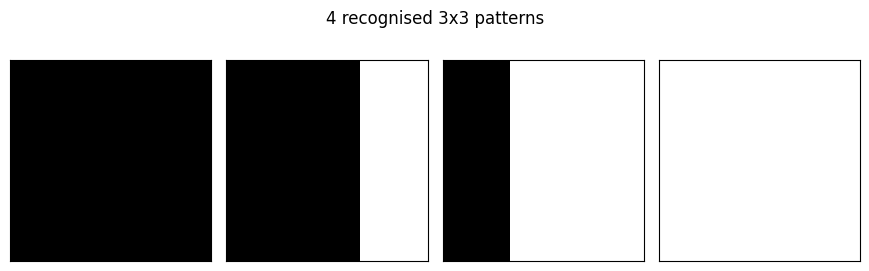

In [11]:
def win_key(w):
    """The nine cells of a 3x3 window, row-major, as a tuple."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """Every complete 3x3 pattern that occurs in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def plot_windows(seen):
    items = sorted(seen)
    fig, axes = plt.subplots(1, len(items), figsize=(2.2 * len(items), 2.8))
    axes = np.atleast_1d(axes)
    for ax, w in zip(axes, items):
        ax.imshow(np.array(w, dtype=float).reshape(3, 3), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{len(items)} recognised 3x3 patterns")
    plt.tight_layout()
    plt.show()


seen = build_windows(grid)
plot_windows(seen)

In [12]:
def pattern_array(seen):
    """Recognised patterns as a (P, 3, 3) int array, in sorted order."""
    return np.array([np.array(p, dtype=int).reshape(3, 3) for p in sorted(seen)])


PATTERNS = pattern_array(seen)


def nearest_pattern(w, patterns):
    """The recognised pattern closest to window w (fewest differing cells).
    Ties: change the centre as little as possible, then lowest sorted order."""
    diffs = (patterns != w).reshape(len(patterns), -1).sum(axis=1)   # Hamming distances
    cands = np.where(diffs == diffs.min())[0]
    if len(cands) > 1:                                               # tie-break 1
        centre_change = (patterns[cands, 1, 1] != w[1, 1]).astype(int)
        cands = cands[centre_change == centre_change.min()]
    return patterns[cands[0]]                                        # tie-break 2: sorted order


def step_seq(field, patterns, rng):
    """One sweep. Visit interior cells in random order; replace each 3x3 window
    with its nearest recognised pattern. Returns (field, cells_changed)."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    changed = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2]
        new = nearest_pattern(w, patterns)
        if not np.array_equal(new, w):
            changed += int((new != w).sum())
            field[r - 1:r + 2, c - 1:c + 2] = new
    return field, changed


def run(field, patterns, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. The input `field` is never modified.
    Prints only when the number of changes moves."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, changed = step_seq(f, patterns, rng)
        if verbose and changed != prev:
            print(f"  sweep {t:5d}: cells changed = {changed}")
            prev = changed
    return f

  sweep     1: cells changed = 1856
  sweep     2: cells changed = 651
  sweep     3: cells changed = 557
  sweep     4: cells changed = 634
  sweep     5: cells changed = 650
  sweep     6: cells changed = 658
  sweep     7: cells changed = 627
  sweep     8: cells changed = 642
  sweep     9: cells changed = 576
  sweep    10: cells changed = 616
  sweep    11: cells changed = 587
  sweep    12: cells changed = 712
  sweep    13: cells changed = 660
  sweep    14: cells changed = 655
  sweep    15: cells changed = 697
  sweep    16: cells changed = 605
  sweep    17: cells changed = 630
  sweep    18: cells changed = 559
  sweep    19: cells changed = 584
  sweep    20: cells changed = 653
  sweep    21: cells changed = 610
  sweep    22: cells changed = 636
  sweep    23: cells changed = 635
  sweep    24: cells changed = 632
  sweep    25: cells changed = 638
  sweep    26: cells changed = 630
  sweep    27: cells changed = 597
  sweep    28: cells changed = 579
  sweep    29: cell

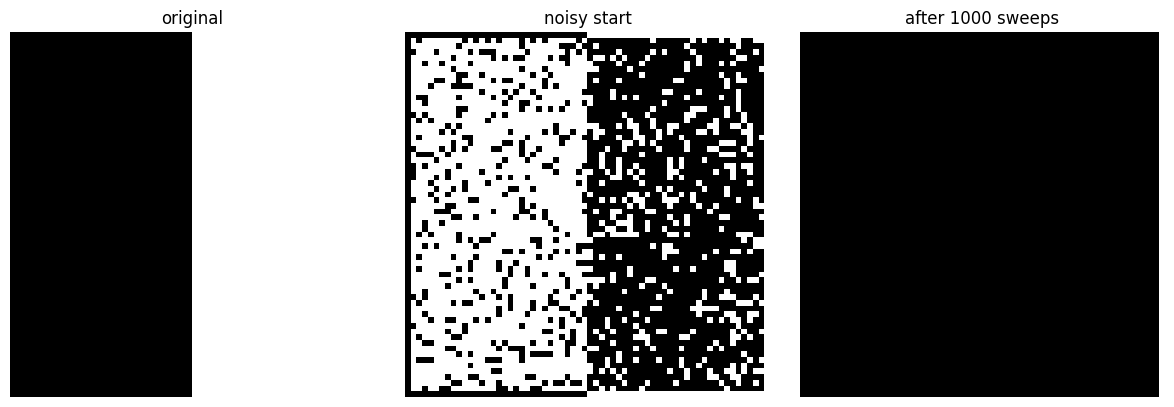

In [13]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


FRAC = 0.8
NOISE_SEED = 15

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final_noisy = run(noisy, PATTERNS)
plot_three(grid, noisy, final_noisy, N)

differing cells per column: [32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55
 56 57 58 59 60 61 62]
column counts: [64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64
 64 64 64 64 64 64 64]


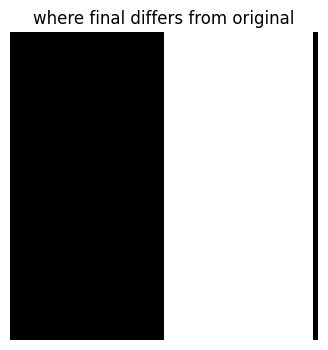

In [14]:
diff = (final_noisy != grid)
print("differing cells per column:", np.where(diff.sum(axis=0) > 0)[0])
print("column counts:", diff.sum(axis=0)[diff.sum(axis=0) > 0])

plt.figure(figsize=(4, 4))
plt.imshow(diff, cmap="gray")
plt.title("where final differs from original")
plt.axis("off")
plt.show()

Repair is perfect, but at a certain point we do see some shift at the boundary. What is also quite interesting as we increase The fraction of cells flipped We see almost a wave pattern reversal. 

Takeaways so far: the center only has a repair radius of 1, so we do tend to get stuck. The whole window nearest pattern works great. But it can cause slight drift, so I will have to try and figure out how to fix that. 

So, full recap so far: first algorithm only flips the center. If you flip and it becomes a recognized pattern, we go with that pattern. If not, nothing changes. 
Second algorithm does the whole window. We compare the current and a pattern that we recognize, and we see the difference between them. I believe it's called the Hamming distance, and whatever pattern we recognize as closer, we will replace it with that. 
Algorithm that we know will try: we'll combine both, so we flip the center to see if that works. If not, fall back to the nearest pattern. 

Our new method is a hybrid approach of our previous two, where in our first we only focus on the center. In our second, we would find the nearest pattern. 

Method 1: the center only one. Never drifts but gets stuck on touching clusters. 
Method 2: a whole window nearest pattern, clears everything but drifts because it rewrites nine cells at a time and can stamp over cells that were already fine. 

Hybrid: For each cell, first try flipping only at the center. If that makes the window recognized, take it. Only if the center flip fails do we fall back to overwriting the whole window with the nearest recognized pattern. 

I think that we will see the center selection do most of the job, and then the second method will fix all stuck positions and potentially drift less now. 

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
N = 1000
SEED = 0     
size = 64    # grid size

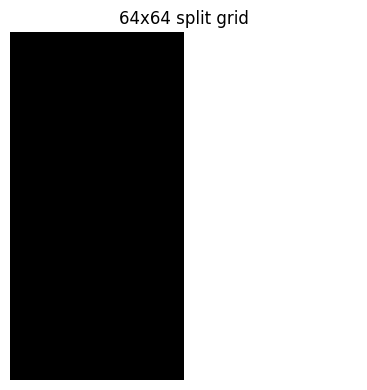

In [17]:
def make_split(size):
    """Left half black (0), right half white (1). One vertical boundary."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(size)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{size}x{size} split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
def win_key(w):
    """The nine cells of a 3x3 window, row-major, as a tuple."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """Every complete 3x3 pattern that occurs in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def pattern_array(seen):
    """Recognised patterns as a (P, 3, 3) int array, in sorted order."""
    return np.array([np.array(p, dtype=int).reshape(3, 3) for p in sorted(seen)])


seen = build_windows(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

4 recognised patterns


In [19]:
def nearest_pattern(w, patterns):
    """The recognised pattern closest to window w (fewest differing cells).
    Ties: change the centre as little as possible, then lowest sorted order."""
    diffs = (patterns != w).reshape(len(patterns), -1).sum(axis=1)
    cands = np.where(diffs == diffs.min())[0]
    if len(cands) > 1:
        centre_change = (patterns[cands, 1, 1] != w[1, 1]).astype(int)
        cands = cands[centre_change == centre_change.min()]
    return patterns[cands[0]]

In [20]:
def step_hybrid(field, seen, patterns, rng):
    """Centre-only where it works; nearest-pattern fallback where it doesn't."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    changed = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2]

        if win_key(w) in seen:                 
            continue

        trial = w.copy()                       # try flipping just the centre
        trial[1, 1] ^= 1
        if win_key(trial) in seen:
            field[r, c] = trial[1, 1]
            changed += 1
            continue

        new = nearest_pattern(w, patterns)     # fallback: whole-window rewrite
        if not np.array_equal(new, w):
            changed += int((new != w).sum())
            field[r - 1:r + 2, c - 1:c + 2] = new
    return field, changed


def run_hybrid(field, seen, patterns, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. Input `field` is never modified."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, changed = step_hybrid(f, seen, patterns, rng)
        if verbose and changed != prev:
            print(f"  sweep {t:5d}: cells changed = {changed}")
            prev = changed
        if changed == 0:
            break
    return f

In [21]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()

  sweep     1: cells changed = 3795
  sweep     2: cells changed = 1443
  sweep     3: cells changed = 878
  sweep     4: cells changed = 765
  sweep     5: cells changed = 608
  sweep     6: cells changed = 508
  sweep     7: cells changed = 392
  sweep     8: cells changed = 416
  sweep     9: cells changed = 338
  sweep    10: cells changed = 266
  sweep    11: cells changed = 315
  sweep    12: cells changed = 377
  sweep    13: cells changed = 266
  sweep    14: cells changed = 203
  sweep    15: cells changed = 150
  sweep    16: cells changed = 121
  sweep    17: cells changed = 109
  sweep    18: cells changed = 111
  sweep    19: cells changed = 98
  sweep    20: cells changed = 92
  sweep    21: cells changed = 96
  sweep    22: cells changed = 94
  sweep    23: cells changed = 78
  sweep    24: cells changed = 85
  sweep    25: cells changed = 97
  sweep    26: cells changed = 83
  sweep    27: cells changed = 82
  sweep    28: cells changed = 77
  sweep    29: cells changed

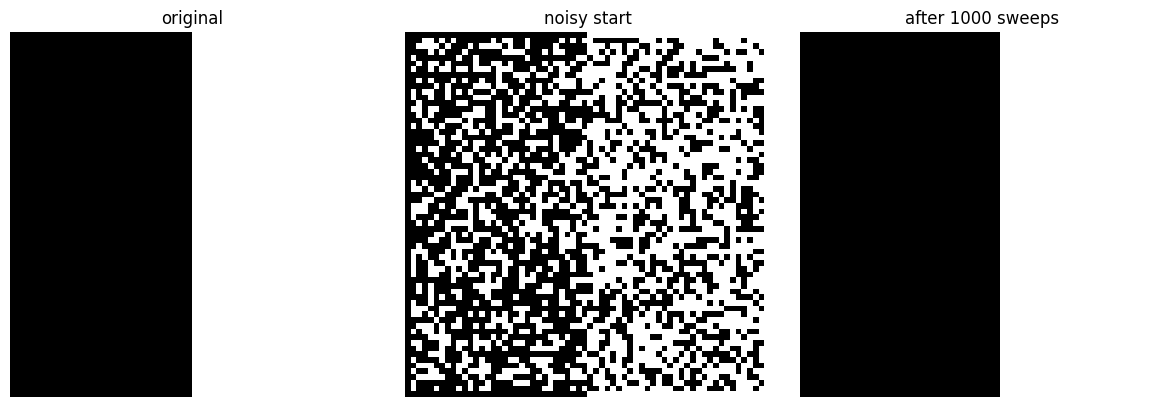

In [22]:
FRAC = 0.4
NOISE_SEED = 15

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final_hybrid = run_hybrid(noisy, seen, PATTERNS)
print("still differing from original:", int((final_hybrid != grid).sum()))
plot_three(grid, noisy, final_hybrid, N)

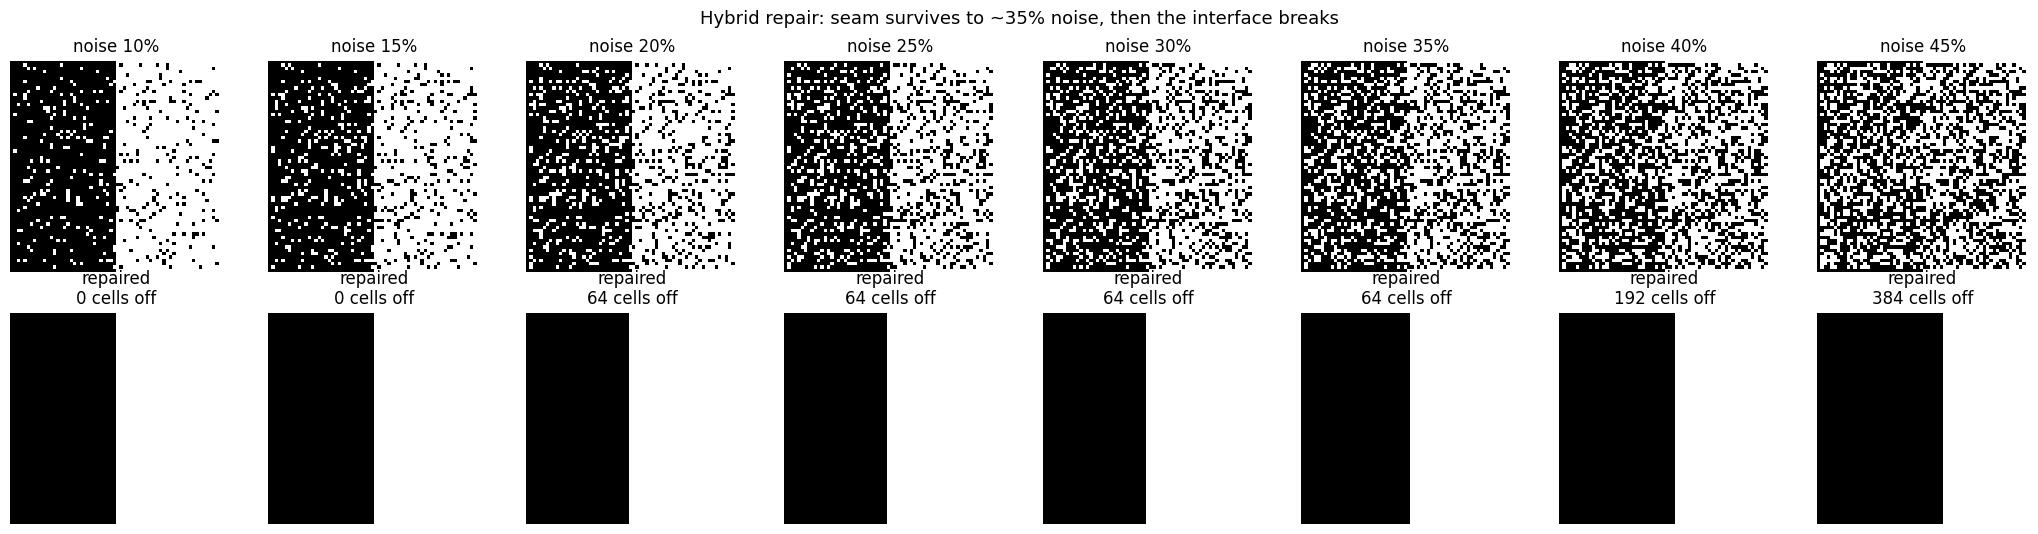

In [23]:
FRACS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]

fig, ax = plt.subplots(2, len(FRACS), figsize=(2.6 * len(FRACS), 5.4))
for j, fr in enumerate(FRACS):
    noisy = add_noise(grid, frac=fr, seed=15)
    out = run_hybrid(noisy, seen, PATTERNS, sweeps=N, seed=SEED, verbose=False)
    ax[0, j].imshow(noisy, cmap="gray", vmin=0, vmax=1)
    ax[0, j].set_title(f"noise {fr:.0%}")
    ax[1, j].imshow(out, cmap="gray", vmin=0, vmax=1)
    ax[1, j].set_title(f"repaired\n{int((out != grid).sum())} cells off")
    for a in (ax[0, j], ax[1, j]):
        a.axis("off")

fig.suptitle("Hybrid repair: seam survives to ~35% noise, then the interface breaks",
             fontsize=13)
plt.tight_layout()
plt.show()

As you can see, it mainly repairs perfectly as we get up to 20%. From 20% onwards, we have one slice down the middle that is incorrect, and then once we get 40%, the shape is gone. 

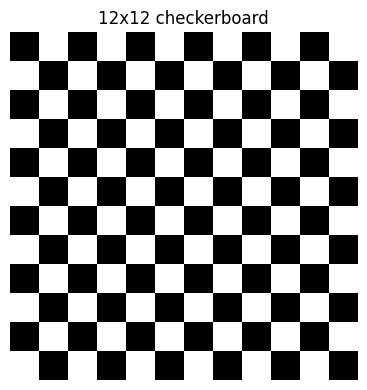

In [24]:
def make_checker(size=12):
    """Checkerboard: cell is 1 when row+col is odd."""
    r = np.arange(size)[:, None]
    c = np.arange(size)[None, :]
    return ((r + c) % 2).astype(int)


grid = make_checker(size=12)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{12}x{12} checkerboard")
plt.axis("off")
plt.tight_layout()
plt.show()

Here's our checkerboard pattern. I'm now going to run our split rules on this checkerboard pattern just to see what outputs. 

still differing from original: 72


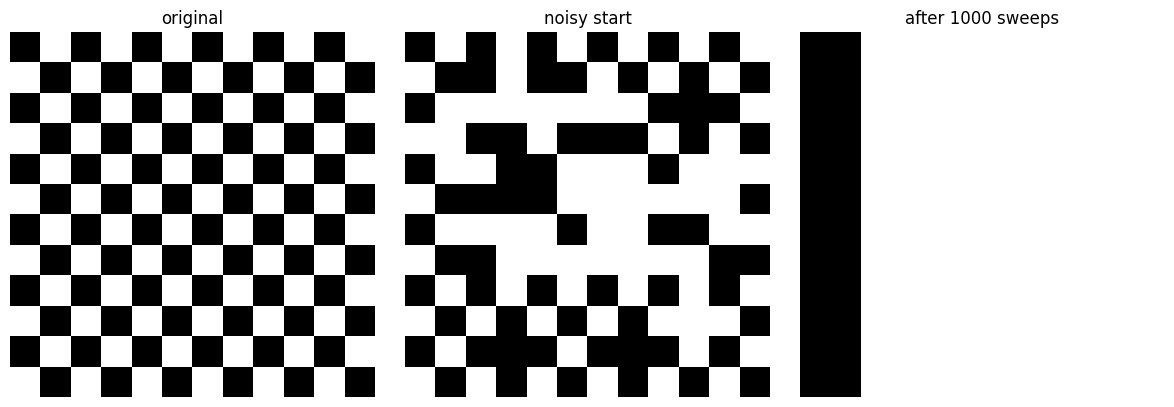

In [25]:
FRAC = 0.40
NOISE_SEED = 0

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final = run_hybrid(noisy, seen, PATTERNS, sweeps=N, seed=SEED, verbose=False)
print("still differing from original:", int((final != grid).sum()))
plot_three(grid, noisy, final, N)

Now we are going to try to make the checkable pattern be recreatable when we add noise. 

In [26]:
grid = make_checker(size=12)
seen = build_windows(grid)
PATTERNS = pattern_array(seen)

print(f"{len(seen)} recognised patterns")   


2 recognised patterns


still differing from original: 144


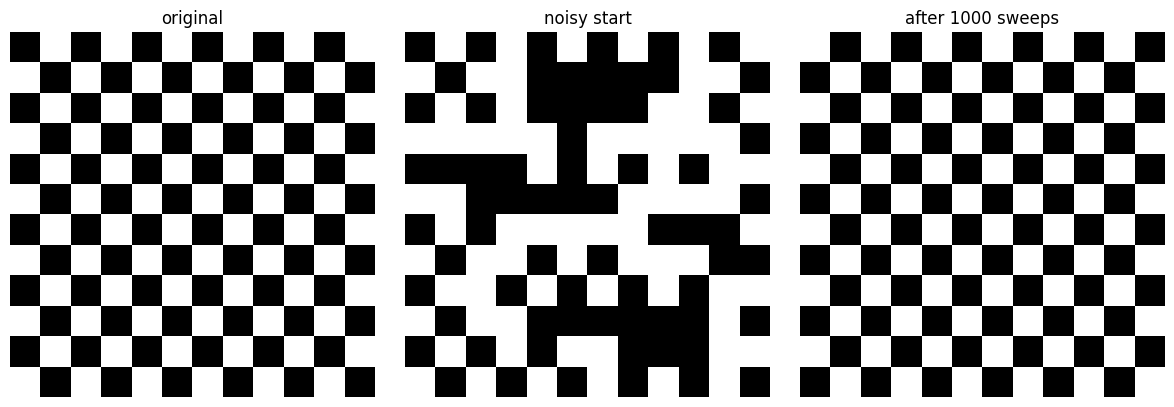

In [27]:
FRAC = 0.5
NOISE_SEED = 15

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final = run_hybrid(noisy, seen, PATTERNS, sweeps=N, seed=SEED, verbose=False)
print("still differing from original:", int((final != grid).sum()))
plot_three(grid, noisy, final, N)

cells differing from original: 144


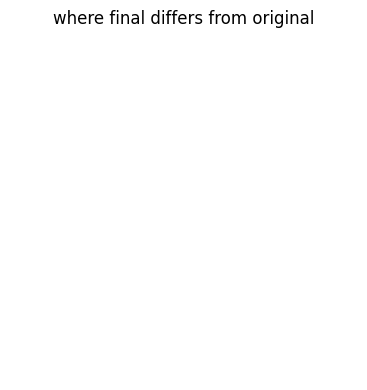

In [28]:
diff = (final != grid)
print("cells differing from original:", int(diff.sum()))

plt.figure(figsize=(4, 4))
plt.imshow(diff, cmap="gray", vmin=0, vmax=1)   # white where it differs, black where it matches
plt.title("where final differs from original")
plt.axis("off")
plt.tight_layout()
plt.show()

As you can see, this works well and recreates a perfect checkerboard. As we push the fraction of noise up higher, we actually see that the board flips and it recreates it perfectly, but white goes where black was and vice versa. 

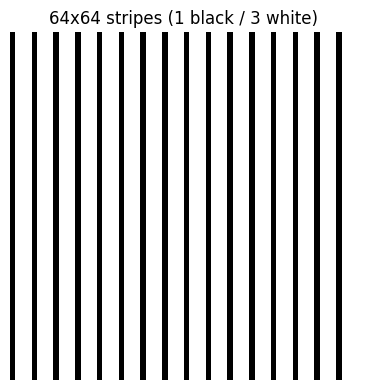

In [29]:
def make_stripes(size, black, white, horizontal=True):
    """Repeating bands: `black` rows/cols of 0, then `white` of 1, repeated."""
    period = black + white
    idx = np.arange(size)
    band = np.where(idx % period < black, 0, 1)     # 0 for first `black`, else 1
    if horizontal:
        g = np.repeat(band[:, None], size, axis=1)
    else:
        g = np.repeat(band[None, :], size, axis=0)
    return g.astype(int)


BLACK = 1        # width of each black band
WHITE = 3       # width of each white band
HORIZONTAL = False 

grid = make_stripes(size, black=BLACK, white=WHITE, horizontal=HORIZONTAL)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{size}x{size} stripes ({BLACK} black / {WHITE} white)")
plt.axis("off")
plt.tight_layout()
plt.show()

4 recognised patterns
differing from original: 256


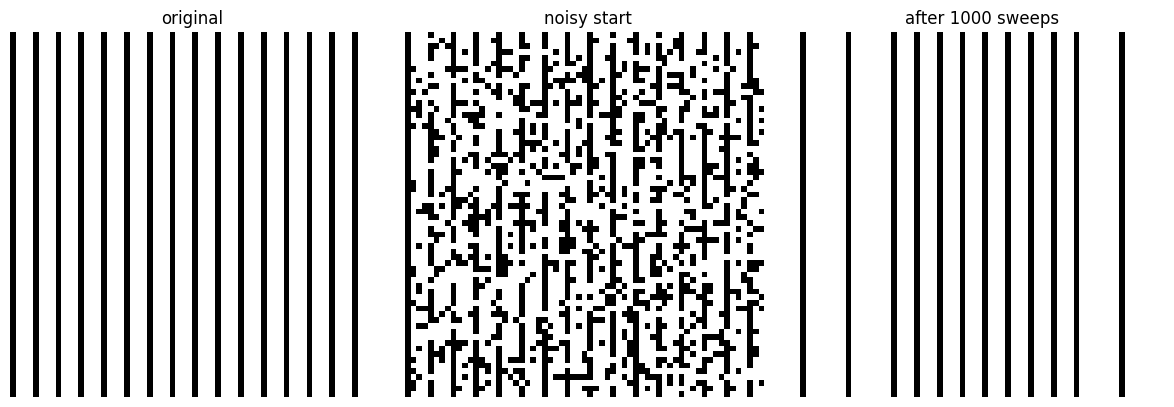

In [30]:
seen = build_windows(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

FRAC = 0.2
NOISE_SEED = 15
noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final = run_hybrid(noisy, seen, PATTERNS, sweeps=N, seed=SEED, verbose=False)

diff = (final != grid)
print("differing from original:", int(diff.sum()))
plot_three(grid, noisy, final, N)

Post-meeting with Evan. 

Now trying periodic boundaries ,And periodic patterns 

In [31]:
import numpy as np
import matplotlib.pyplot as plt

N = 500      
SEED = 15    

Collect all patterns and wrap boundary. 

In [32]:
def win_key(w):
    """The nine cells of a 3x3 window, row-major, as a tuple (hashable key)."""
    return tuple(int(x) for x in w.ravel())


def build_windows_periodic(grid):
    """Every 3x3 pattern in the grid, reading neighbours with wrap-around.
    Covers all rows*cols cells, not just the interior."""
    pad = np.pad(grid, 1, mode="wrap")
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows + 1):
        for c in range(1, cols + 1):
            seen.add(win_key(pad[r - 1:r + 2, c - 1:c + 2]))
    return seen


def pattern_array(seen):
    """Recognised patterns as a (P, 3, 3) int array, in sorted order."""
    return np.array([np.array(p, dtype=int).reshape(3, 3) for p in sorted(seen)])

Here we're making the grid with the circle, checkered and lines. 

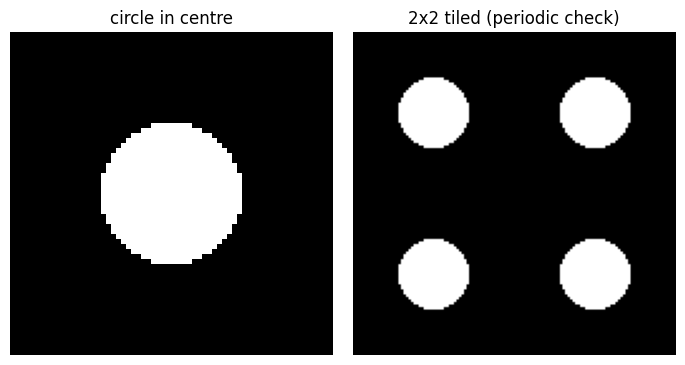

In [33]:
def make_circle(size, radius):
    """Filled disk (1) centred in a field of 0. Uniform border, so it tiles."""
    yy, xx = np.mgrid[0:size, 0:size]
    cy = cx = (size - 1) / 2
    return ((yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2).astype(int)


def make_checker(size=12):
    """Checkerboard; tiles cleanly when size is even."""
    r = np.arange(size)[:, None]
    c = np.arange(size)[None, :]
    return ((r + c) % 2).astype(int)


def make_stripes(size, black, white, horizontal=True):
    """Repeating bands; tiles cleanly when size % (black + white) == 0."""
    period = black + white
    idx = np.arange(size)
    band = np.where(idx % period < black, 0, 1)
    if horizontal:
        return np.repeat(band[:, None], size, axis=1).astype(int)
    return np.repeat(band[None, :], size, axis=0).astype(int)


def show_tiled(grid, title):
    fig, ax = plt.subplots(1, 2, figsize=(7, 3.6))
    ax[0].imshow(grid, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(title)
    ax[1].imshow(np.tile(grid, (2, 2)), cmap="gray", vmin=0, vmax=1)
    ax[1].set_title("2x2 tiled (periodic check)")
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()


show_tiled(make_circle(64, 14), "circle in centre")

Same logic before if it's a recognized pattern. We leave it. If it is unrecognized, we flip the center until it is recognized. If it is not, we use the hybrid approach. 

In [34]:
def nearest_pattern(w, patterns):
    """Recognised pattern closest to window w by Hamming distance.
    Ties: change the centre as little as possible, then lowest sorted order."""
    diffs = (patterns != w).reshape(len(patterns), -1).sum(axis=1)
    cands = np.where(diffs == diffs.min())[0]
    if len(cands) > 1:
        centre_change = (patterns[cands, 1, 1] != w[1, 1]).astype(int)
        cands = cands[centre_change == centre_change.min()]
    return patterns[cands[0]]


def sweep_sync(field, seen, patterns, mode="hybrid"):
    """One synchronous sweep with periodic boundaries.
    mode='center' -> Method 1 only; mode='hybrid' -> Method 1 + nearest-pattern fallback."""
    rows, cols = field.shape
    pad = np.pad(field, 1, mode="wrap")
    nxt = field.copy()
    for r in range(rows):
        for c in range(cols):
            w = pad[r:r + 3, c:c + 3]          # periodic 3x3 of (r, c)
            if win_key(w) in seen:
                continue
            trial = w.copy()
            trial[1, 1] ^= 1                    # try flipping just the centre
            if win_key(trial) in seen:
                nxt[r, c] = trial[1, 1]
                continue
            if mode == "hybrid":               # fallback: centre of nearest pattern
                nxt[r, c] = int(nearest_pattern(w, patterns)[1, 1])
    return nxt, int((nxt != field).sum())


def run_sync(field, seen, patterns, mode="hybrid", sweeps=N, verbose=True):
    """Repeat synchronous sweeps until a fixed point or 2-cycle. Input is never modified."""
    f = field.copy()
    prev2 = None
    for t in range(1, sweeps + 1):
        nxt, changed = sweep_sync(f, seen, patterns, mode)
        if changed == 0:
            if verbose:
                print(f"fixed point at sweep {t}")
            return nxt
        if prev2 is not None and np.array_equal(nxt, prev2):
            if verbose:
                print(f"2-cycle at sweep {t}")
            return nxt
        prev2 = f
        f = nxt
    if verbose:
        print("hit sweep cap")
    return f

Adding noise. 

In [35]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of ALL cells (no protected border now)."""
    rng = np.random.default_rng(seed)
    return (field ^ (rng.random(field.shape) < frac)).astype(int)


def plot_three(original, start, final, title=""):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, "repaired")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

58 recognised patterns
Method 1 (centre only) cells off: 155
Hybrid              cells off: 32


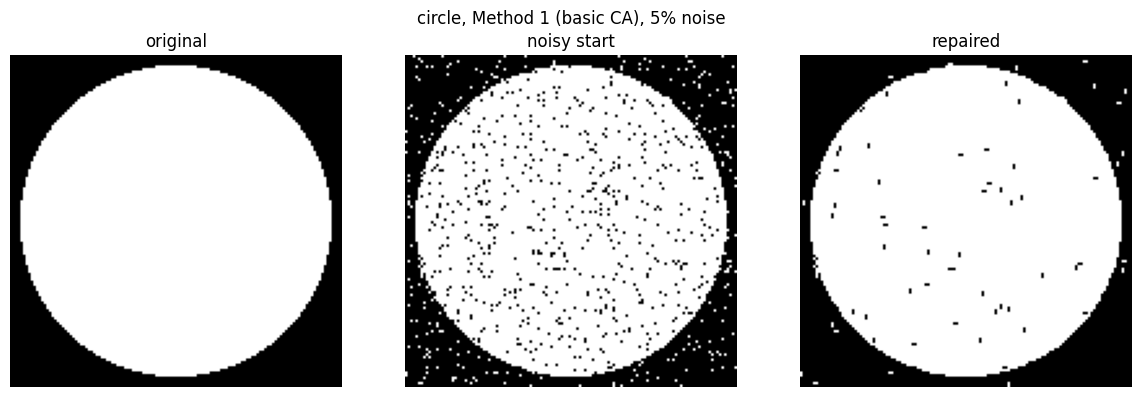

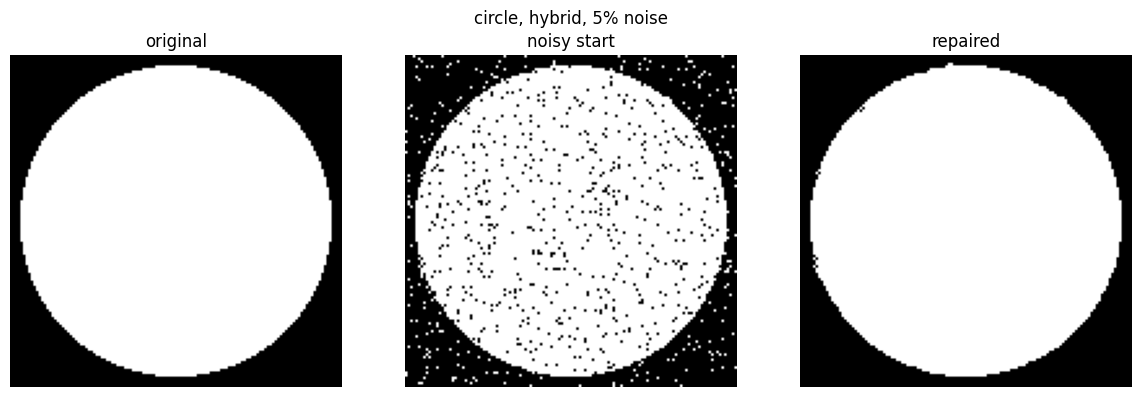

In [36]:
grid = make_circle(size=128, radius=60)
seen = build_windows_periodic(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

FRAC = 0.05
noisy = add_noise(grid, FRAC, seed=SEED)

out_m1 = run_sync(noisy, seen, PATTERNS, mode="center", verbose=False)
out_hy = run_sync(noisy, seen, PATTERNS, mode="hybrid", verbose=False)
print("Method 1 (centre only) cells off:", int((out_m1 != grid).sum()))
print("Hybrid              cells off:", int((out_hy != grid).sum()))

plot_three(grid, noisy, out_m1, f"circle, Method 1 (basic CA), {FRAC:.0%} noise")
plot_three(grid, noisy, out_hy, f"circle, hybrid, {FRAC:.0%} noise")

As we can see, the images look great, but we can still visually see specks appearing. The reason why these are not flagged by the code is that if we zoom into the circle, we can see the rigid edges create patterns of white and black. Those patterns cannot be separated from learned patterns locally, as they are valid patterns, whereas globally we can see it is an issue. 


Making the circle a bigger proportion of the image seems to fix this issue entirely. 

Now we will try on different images, like a random blob. 

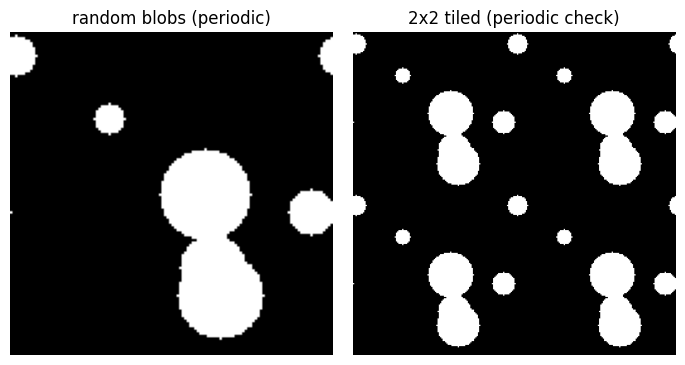

In [37]:
def make_blobs(size, n, rmin, rmax, seed=0):
    """n filled disks of random radius on a torus (wrap-around) -> periodic."""
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:size, 0:size]
    g = np.zeros((size, size), dtype=int)
    for _ in range(n):
        cy, cx = rng.integers(0, size, size=2)
        rad = rng.integers(rmin, rmax + 1)
        dy = np.minimum(np.abs(yy - cy), size - np.abs(yy - cy))
        dx = np.minimum(np.abs(xx - cx), size - np.abs(xx - cx))
        g[dy ** 2 + dx ** 2 <= rad ** 2] = 1
    return g


blobs = make_blobs(size=128, n=8, rmin=6, rmax=18, seed=0)
show_tiled(blobs, "random blobs (periodic)")

77 recognised patterns
46 cells off, 24 of them accepted as valid


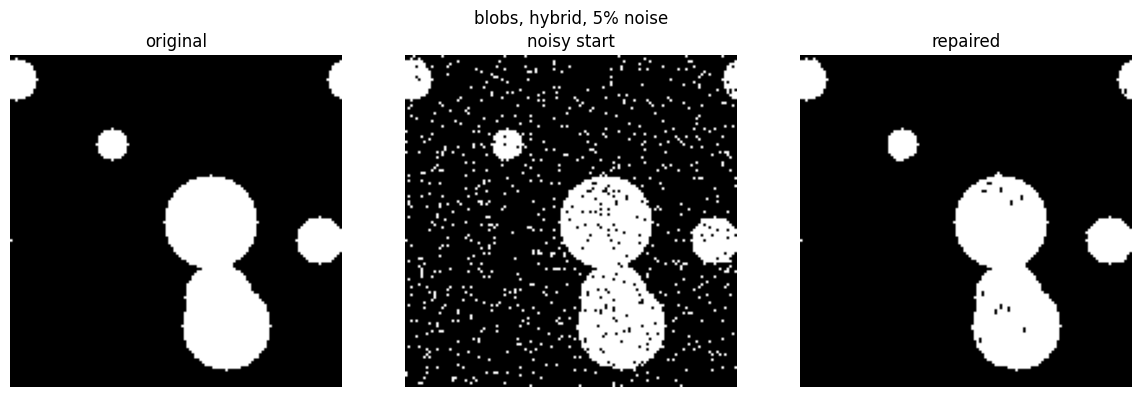

In [38]:
grid = blobs
seen = build_windows_periodic(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

FRAC = 0.05
noisy = add_noise(grid, FRAC, seed=SEED)
out = run_sync(noisy, seen, PATTERNS, mode="hybrid", verbose=False)

diff = out != grid
pad = np.pad(out, 1, mode="wrap")
legal = sum(win_key(pad[r:r + 3, c:c + 3]) in seen for r, c in zip(*np.where(diff)))
print(f"{int(diff.sum())} cells off, {legal} of them accepted as valid")
plot_three(grid, noisy, out, f"blobs, hybrid, {FRAC:.0%} noise")

Having the issue of specks appearing again, this is due to the unique patterns around the edges. To fix this, we will add a simple majority rule. 

In [39]:

def clean_specks(field, thresh=7, rounds=3):
    """Flip a cell only if >= thresh of its 8 periodic neighbours disagree.
    thresh=7/8 -> only near-surrounded specks & pits; real edges (neighbours
    split) are left alone, so blob outlines don't move."""
    f = field.copy()
    for _ in range(rounds):
        pad = np.pad(f, 1, mode="wrap")
        white_nb = (pad[:-2, :-2] + pad[:-2, 1:-1] + pad[:-2, 2:] +
                    pad[1:-1, :-2]                 + pad[1:-1, 2:] +
                    pad[2:, :-2]  + pad[2:, 1:-1]  + pad[2:, 2:])
        black_nb = 8 - white_nb
        flip_white = (f == 1) & (black_nb >= thresh)   # white speck in black
        flip_black = (f == 0) & (white_nb >= thresh)   # black pit in white
        f = np.where(flip_white, 0, np.where(flip_black, 1, f))
    return f

hybrid alone off: 46
hybrid+cleanup off: 23


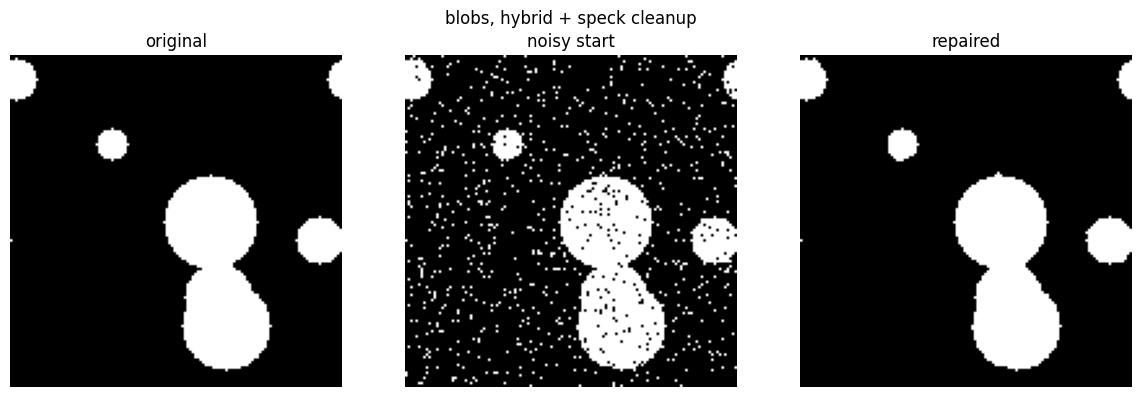

In [40]:
out = run_sync(noisy, seen, PATTERNS, mode="hybrid", verbose=False)
clean = clean_specks(out, thresh=7, rounds=3)
print("hybrid alone off:", int((out != grid).sum()))
print("hybrid+cleanup off:", int((clean != grid).sum()))
plot_three(grid, noisy, clean, "blobs, hybrid + speck cleanup")

Now I'm moving from fixed shapes to a random two-phase field. 

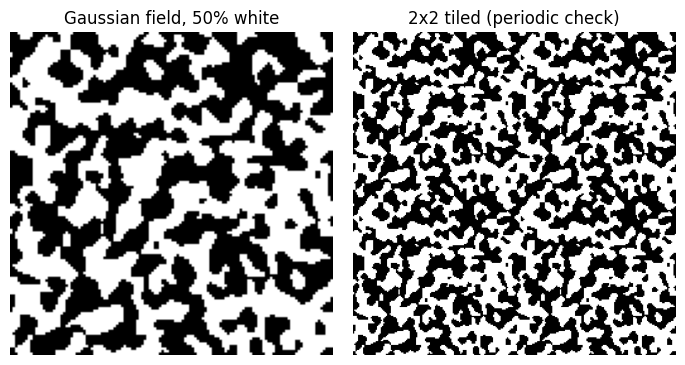

actual white fraction: 0.5


In [41]:
def make_field(size, scale, frac=0.5, seed=0):
    """Smooth periodic Gaussian field thresholded to a target phase fraction.
    frac = fraction of cells that end up white (1). frac=0.5 -> even split."""
    rng = np.random.default_rng(seed)
    white = rng.normal(size=(size, size))
    fx = np.fft.fftfreq(size)[:, None]
    fy = np.fft.fftfreq(size)[None, :]
    freq2 = fx ** 2 + fy ** 2
    filt = np.exp(-((2 * np.pi) ** 2) * freq2 * (scale ** 2) / 2.0)
    field = np.fft.ifft2(np.fft.fft2(white) * filt).real
    thresh = np.quantile(field, 1 - frac)        # keep the top `frac` as white
    return (field > thresh).astype(int)


field = make_field(size=128, scale=2, frac=0.5, seed=0)   # ~30% white
show_tiled(field, "Gaussian field, 50% white")
print("actual white fraction:", field.mean().round(3))

189 recognised patterns
hybrid          off: 400
hybrid + cleanup off: 383


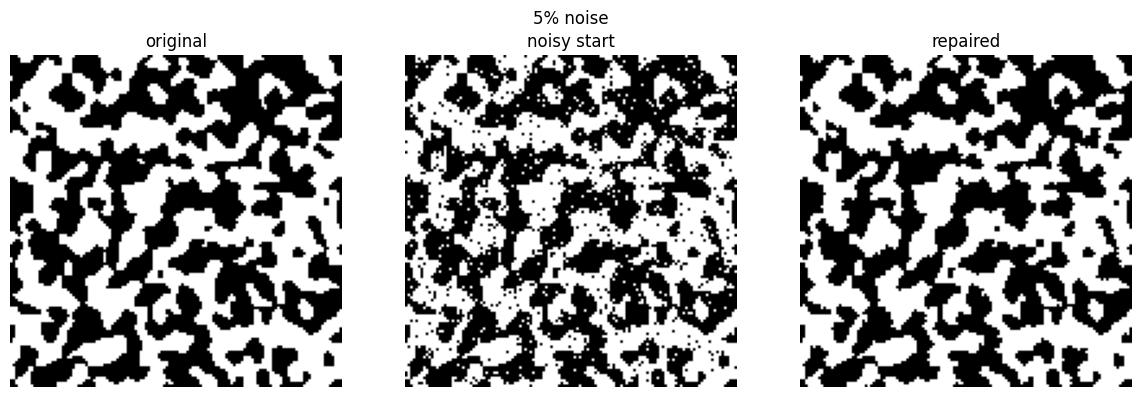

In [42]:
grid = field
seen = build_windows_periodic(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

FRAC = 0.05
noisy = add_noise(grid, FRAC, seed=SEED)
out = run_sync(noisy, seen, PATTERNS, mode="hybrid", verbose=False)
clean = clean_specks(out, thresh=7, rounds=3)

print("hybrid          off:", int((out != grid).sum()))
print("hybrid + cleanup off:", int((clean != grid).sum()))
plot_three(grid, noisy, clean, f"{FRAC:.0%} noise")

383 cells off (2.34%)


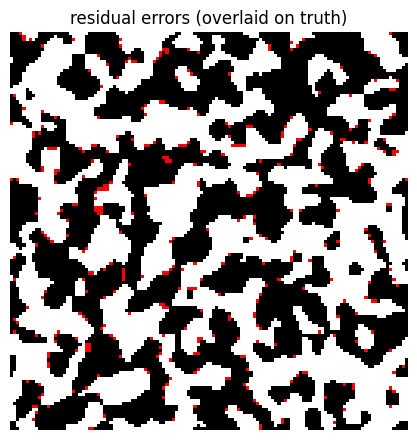

In [43]:
diff = clean != grid
print(f"{diff.sum()} cells off ({diff.mean():.2%})")
plt.figure(figsize=(4.5, 4.5))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.imshow(np.ma.masked_where(~diff, diff), cmap="autumn")
plt.title("residual errors (overlaid on truth)")
plt.axis("off"); plt.tight_layout(); plt.show()

As we can see, the new method of the hybrid approach plus the clean-up stores the field almost perfectly by the way, and then 2.34% of cells remain off at 5% noise. This is largely at the boundary areas. Some, not, but mostly at the boundary areas. Now it's time to maybe fix this or decide where to go next. 

I'm just going to score by statistics rather than just pure pixel. Need to look at the proportion and density and two-point conversion and stuff. Just to make sure that the underlying Gaussian field is actually the same. It looks visually the same, but obviously the amount of pixel difference doesn't necessarily tell us that. 

truth      proportion=0.500   interface=0.115
noisy      proportion=0.499   interface=0.191
repaired   proportion=0.503   interface=0.121


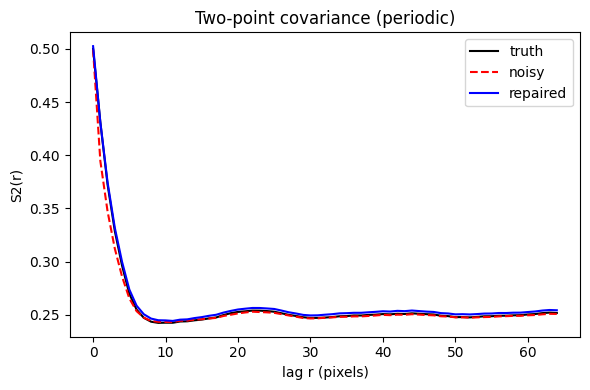

In [44]:
def interface_density(f):
    """Fraction of periodic neighbour pairs that differ (boundary-length proxy)."""
    right = (f != np.roll(f, -1, axis=1)).mean()
    down  = (f != np.roll(f, -1, axis=0)).mean()
    return 0.5 * (right + down)


def two_point_corr(f, rmax=None):
    """Radially-averaged two-point covariance S2(r) via periodic FFT autocorrelation."""
    n = f.size
    F = np.fft.fft2(f)
    ac = np.fft.fftshift(np.fft.ifft2(F * np.conj(F)).real / n)   # S2 at every lag
    size = f.shape[0]
    c = size // 2
    yy, xx = np.mgrid[0:size, 0:size]
    rr = np.hypot(yy - c, xx - c).astype(int)
    if rmax is None:
        rmax = size // 2
    S2 = np.array([ac[rr == r].mean() for r in range(rmax + 1)])
    return np.arange(rmax + 1), S2


for name, img in [("truth", grid), ("noisy", noisy), ("repaired", clean)]:
    print(f"{name:9s}  proportion={img.mean():.3f}   interface={interface_density(img):.3f}")

r, s_truth = two_point_corr(grid)
_, s_noisy = two_point_corr(noisy)
_, s_rep   = two_point_corr(clean)

plt.figure(figsize=(6, 4))
plt.plot(r, s_truth, "k-",  label="truth")
plt.plot(r, s_noisy, "r--", label="noisy")
plt.plot(r, s_rep,   "b-",  label="repaired")
plt.xlabel("lag r (pixels)"); plt.ylabel("S2(r)")
plt.title("Two-point covariance (periodic)")
plt.legend(); plt.tight_layout(); plt.show()

So far, we've just been restoring images after adding noise. So I just wanna test if we can actually grow materials with the learned rules. May not work, just something I want to try. 

2-cycle at sweep 14
truth       proportion=0.500  interface=0.115
seed noise  proportion=0.491  interface=0.501
grown       proportion=0.513  interface=0.247


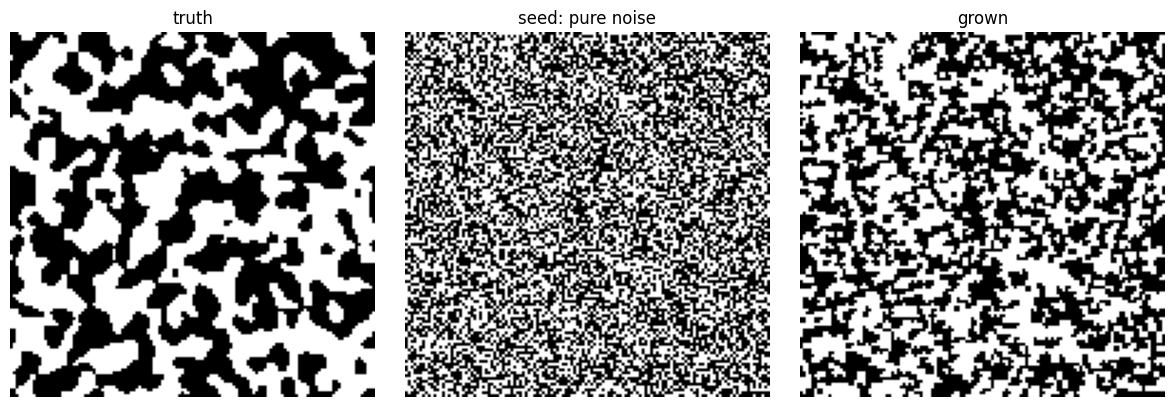

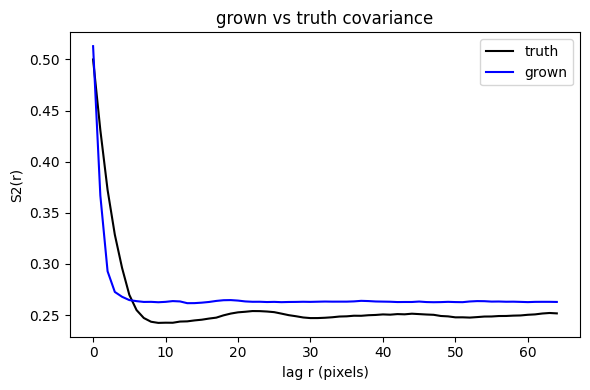

In [45]:
SWEEPS = 100  

rng = np.random.default_rng(SEED)
seed_noise = (rng.random(grid.shape) < 0.5).astype(int)   # pure 50/50 static

grown = run_sync(seed_noise, seen, PATTERNS, mode="hybrid", sweeps=SWEEPS, verbose=True)
grown = clean_specks(grown, thresh=7, rounds=3)

for name, img in [("truth", grid), ("seed noise", seed_noise), ("grown", grown)]:
    print(f"{name:11s} proportion={img.mean():.3f}  interface={interface_density(img):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (t, img) in zip(ax, [("truth", grid), ("seed: pure noise", seed_noise), ("grown", grown)]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

r, s_t = two_point_corr(grid)
_, s_g = two_point_corr(grown)
plt.figure(figsize=(6, 4))
plt.plot(r, s_t, "k-", label="truth"); plt.plot(r, s_g, "b-", label="grown")
plt.xlabel("lag r (pixels)"); plt.ylabel("S2(r)"); plt.title("grown vs truth covariance")
plt.legend(); plt.tight_layout(); plt.show()

Growing from pure noise, collapsing to blobs like I thought would happen. So I'm going to try to shrink the field and grow there. each 3-pixel neighborhood now spans K real pixels., the blobs come out k times bigger, then upsize it so we will have a blobby-looking image, and then run again. 

In [46]:
def block_downsample(f, k):
    """Shrink by k via block majority. Works for any k (periodic pad to a multiple)."""
    n = f.shape[0]
    sc = -(-n // k)                      # ceil(n/k)
    pad = sc * k - n
    fp = np.pad(f, ((0, pad), (0, pad)), mode="wrap")
    return (fp.reshape(sc, k, sc, k).mean(axis=(1, 3)) > 0.5).astype(int)

def upsample(f, k, out):
    """Blow up by k, then crop back to `out` size."""
    up = np.repeat(np.repeat(f, k, axis=0), k, axis=1)
    return up[:out, :out]

fixed point at sweep 12
fixed point at sweep 1
truth                  proportion=0.500  interface=0.115
grown (3x3)            proportion=0.513  interface=0.247
grown (coarse-to-fine) proportion=0.455  interface=0.086


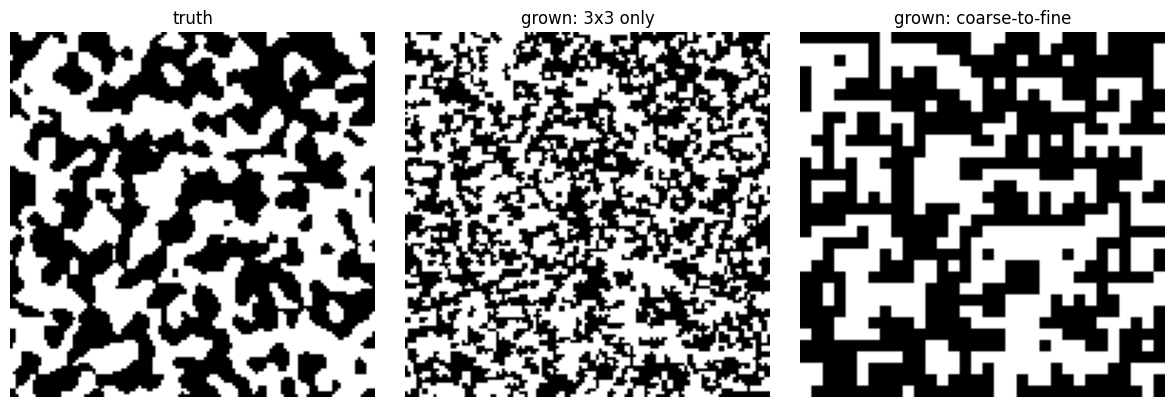

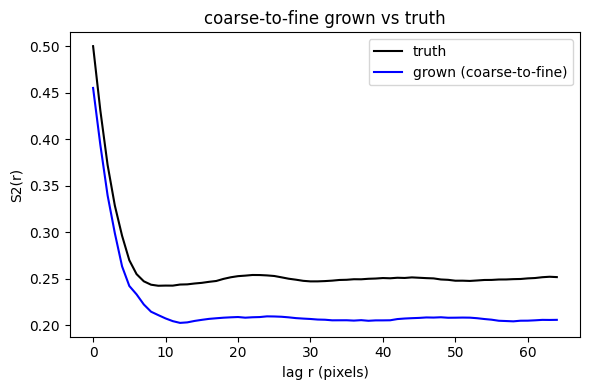

In [47]:
K = 4   # coarsening factor: grown blobs come out ~K x bigger. Try 3-5.

# --- coarse stage: learn + grow on a shrunken copy ---
coarse_truth = block_downsample(grid, K)
seen_c = build_windows_periodic(coarse_truth)
P_c = pattern_array(seen_c)

rng = np.random.default_rng(SEED)
coarse_seed  = (rng.random(coarse_truth.shape) < 0.5).astype(int)   # pure static, coarse grid
coarse_grown = run_sync(coarse_seed, seen_c, P_c, mode="hybrid", sweeps=SWEEPS, verbose=True)

# --- fine stage: upsample the big blobs, refine edges with the fine 3x3 rule ---
seed_fine = upsample(coarse_grown, K, out=grid.shape[0])
grown2 = run_sync(seed_fine, seen, PATTERNS, mode="hybrid", sweeps=SWEEPS, verbose=True)
grown2 = clean_specks(grown2, thresh=7, rounds=3)

for name, img in [("truth", grid), ("grown (3x3)", grown), ("grown (coarse-to-fine)", grown2)]:
    print(f"{name:22s} proportion={img.mean():.3f}  interface={interface_density(img):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (t, img) in zip(ax, [("truth", grid), ("grown: 3x3 only", grown), ("grown: coarse-to-fine", grown2)]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

r, s_t = two_point_corr(grid)
_, s_g = two_point_corr(grown2)
plt.figure(figsize=(6, 4))
plt.plot(r, s_t, "k-", label="truth"); plt.plot(r, s_g, "b-", label="grown (coarse-to-fine)")
plt.xlabel("lag r (pixels)"); plt.ylabel("S2(r)"); plt.title("coarse-to-fine grown vs truth")
plt.legend(); plt.tight_layout(); plt.show()

So we've got the blob size right. So it technically is very similar, but it looks disgusting. Essentially, our boundaries are just dead straight, which is not the case in the real image. So I'm going to try to add a blur to the image so that it hasn't got these straight lines, and then try and fix it from there. 

In [48]:
def smooth_binary(f, scale, frac):
    """Periodic blur + threshold at TARGET proportion `frac` (fixes drift + de-blocks)."""
    n = f.shape[0]
    fx = np.fft.fftfreq(n)[:, None]; fy = np.fft.fftfreq(n)[None, :]
    filt = np.exp(-((2 * np.pi) ** 2) * (fx ** 2 + fy ** 2) * (scale ** 2) / 2.0)
    blurred = np.fft.ifft2(np.fft.fft2(f.astype(float)) * filt).real
    return (blurred > np.quantile(blurred, 1 - frac)).astype(int)

fixed point at sweep 10
fixed point at sweep 3
truth                  proportion=0.500  interface=0.115
grown (3x3)            proportion=0.513  interface=0.247
grown (coarse-to-fine) proportion=0.499  interface=0.106


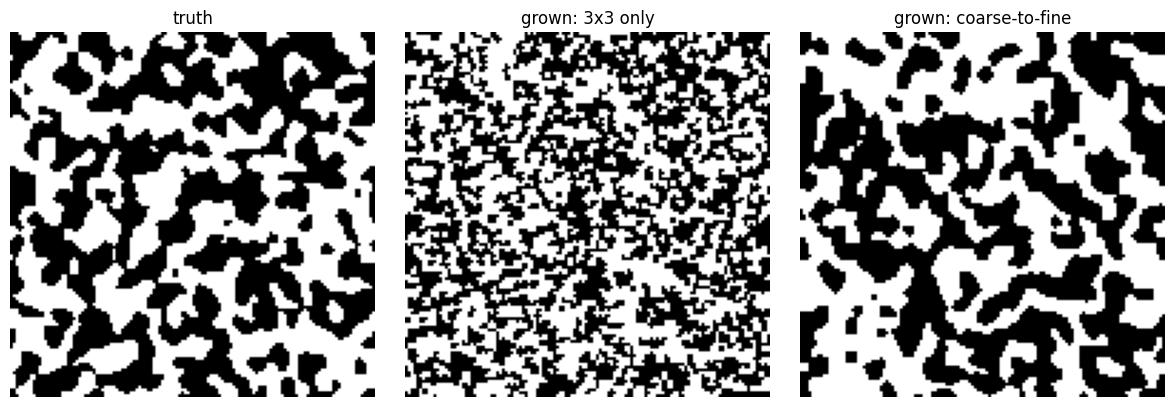

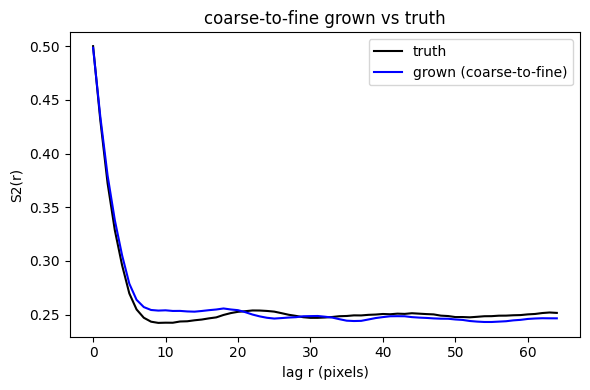

In [49]:
K =2    # drop to k=3 so blobs aren't oversized

coarse_truth = block_downsample(grid, K)
seen_c = build_windows_periodic(coarse_truth)
P_c = pattern_array(seen_c)

rng = np.random.default_rng(SEED)
coarse_seed  = (rng.random(coarse_truth.shape) < 0.5).astype(int)
coarse_grown = run_sync(coarse_seed, seen_c, P_c, mode="hybrid", sweeps=SWEEPS, verbose=True)

seed_fine = upsample(coarse_grown, K, out=grid.shape[0])
seed_fine = smooth_binary(seed_fine, scale=1.5, frac=grid.mean())
grown2 = run_sync(seed_fine, seen, PATTERNS, mode="hybrid", sweeps=SWEEPS, verbose=True)
grown2 = clean_specks(grown2, thresh=7, rounds=3)

for name, img in [("truth", grid), ("grown (3x3)", grown), ("grown (coarse-to-fine)", grown2)]:
    print(f"{name:22s} proportion={img.mean():.3f}  interface={interface_density(img):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (t, img) in zip(ax, [("truth", grid), ("grown: 3x3 only", grown), ("grown: coarse-to-fine", grown2)]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

r, s_t = two_point_corr(grid)
_, s_g = two_point_corr(grown2)
plt.figure(figsize=(6, 4))
plt.plot(r, s_t, "k-", label="truth"); plt.plot(r, s_g, "b-", label="grown (coarse-to-fine)")
plt.xlabel("lag r (pixels)"); plt.ylabel("S2(r)"); plt.title("coarse-to-fine grown vs truth")
plt.legend(); plt.tight_layout(); plt.show()

To the eye they don't look the same, but statistically they're very similar because the measures we matched (proportion, interface, S₂) are low-order and don't capture blob shape or arrangement.

What we're measuring with now, proportion interface S2, are all lower order. They miss out on their connectivity. Which is why visually it differs from the real answer/image Going to try Minkowski Functionals. Which gives a topological measure of how connected the structure is 

In [50]:
def minkowski(f):
    """2D Minkowski functionals of the white (1) phase, periodic.
    Returns (area, perimeter, euler): area = phase fraction, perimeter = boundary
    length per cell, euler = (#blobs - #holes) via 2x2 bit-quads (8-connected)."""
    f = f.astype(bool)
    n = f.size
    area = f.mean()
    perimeter = ((f != np.roll(f, -1, axis=1)).sum() + (f != np.roll(f, -1, axis=0)).sum()) / n
    a = f
    b = np.roll(f, -1, axis=1)
    c = np.roll(f, -1, axis=0)
    d = np.roll(np.roll(f, -1, axis=0), -1, axis=1)
    s = a.astype(int) + b + c + d
    Q1 = np.sum(s == 1)
    Q3 = np.sum(s == 3)
    QD = np.sum((a & d & ~b & ~c) | (b & c & ~a & ~d))
    euler = (Q1 - Q3 + 2 * QD) / 4.0
    return area, perimeter, euler

for name, img in [("truth", grid), ("grown 3x3", grown), ("grown c2f", grown2)]:
    A, P, X = minkowski(img)
    print(f"{name:10s} area={A:.3f}  perimeter={P:.3f}  euler={X:+.1f}")

truth      area=0.500  perimeter=0.231  euler=+0.0
grown 3x3  area=0.513  perimeter=0.495  euler=+102.0
grown c2f  area=0.499  perimeter=0.212  euler=-10.0


Area and the perimeter match up fine, but the Euler number is the one that shows the difference. Truth is about 0. The cost of finding grow is -10, which is close, but the plain 3 by 3 grow is +102. That just means it broke into tiny separate blobs, which we see. So the process after that does actually get us relatively close to the real answer. 

I think the two-phase stuff is done now. So I think I should probably move on to three phases like I was doing originally. That would just be adding an extra threshold condition. Which would give the lithotype map with three materials And then I could run the pipeline I already have, so repair noise, et cetera. And score it with the same measures:
- the propulsion
- the interface
- S2
- the Minkowskis

And that should work fine. There will be more unique patterns, and maybe we'll have more things that we don't recognize, but I'm sure the hybrid approach and a bit of majority rule will be fine. 

One thing I could look at is measuring connectivity/percolation properly. I'm trying to get the CA itself to do the growing rather than leaning on the blue to shape the blobs. 


Further down the line then is the inverse problem. How we want to move towards that, I'm unsure, but I think we have a good, solid base now to maybe get on to some other things. 

Now we will be building our test suite. 


In [51]:
import numpy as np

def fourier_spectrum(field, nbins=None):
    """
    Radially-averaged power spectrum of a 2D field.
    Returns (freq, power): power at each radial spatial frequency.
    Low freq = large-scale structure (big blobs),
    high freq = fine texture.
    """
    f = np.asarray(field, dtype=float)
    f = f - f.mean()                      # drop the DC / mean term so it doesn't dominate

    # 2D FFT -> power spectrum, shifted so freq 0 is in the centre
    F = np.fft.fftshift(np.fft.fft2(f))
    power2d = np.abs(F)**2

    # radial distance of every pixel from the centre (in frequency space)
    ny, nx = f.shape
    cy, cx = ny // 2, nx // 2
    y, x = np.indices((ny, nx))
    r = np.sqrt((y - cy)**2 + (x - cx)**2)

    # bin the 2D power by radius -> 1D radial average
    r = r.astype(int)
    if nbins is None:
        nbins = r.max() + 1
    tbin = np.bincount(r.ravel(), weights=power2d.ravel(), minlength=nbins)
    nr   = np.bincount(r.ravel(), minlength=nbins)
    radial = tbin / np.maximum(nr, 1)     # avoid divide-by-zero

    freq = np.arange(len(radial))
    return freq, radial

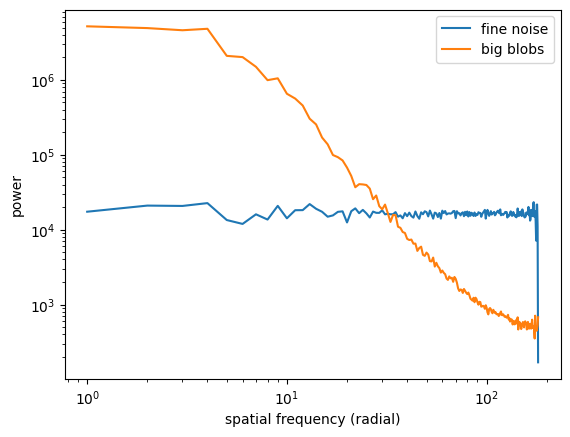

In [52]:
import matplotlib.pyplot as plt

# fine random field vs a smooth blobby field
rng = np.random.default_rng(0)
fine = rng.random((256, 256)) > 0.5

# quick blobby field: blur the noise then threshold
from scipy.ndimage import gaussian_filter
blob = gaussian_filter(fine.astype(float), 6) > 0.5

for name, fld in [("fine noise", fine), ("big blobs", blob)]:
    fr, pw = fourier_spectrum(fld)
    plt.loglog(fr[1:], pw[1:], label=name)

plt.xlabel("spatial frequency (radial)")
plt.ylabel("power")
plt.legend(); plt.show()

Fourier findings.

Okay so this measures what size of stuff is in the image. Left of the graph is big blobs, right is fine detail. High up means there's lots of it, low down means barely any.

The big blobs line is high on the left and drops off to the right — so lots of big stuff, almost no fine detail, which is right because it's a blobby image. The fine noise line is flat all the way across, because random noise is an equal mix of every size.

The useful bit is where the two lines cross — that point is basically the blob size. So if I run this on a real image and my generated one, if the blobs are the right size the lines will cross in the same place. If mine crosses further right my blobs are too small, further left they're too big. So it's basically a ruler for blob size.

Next descriptor: wavelets. This splits the image into layers by scale , like looking at it through a coarse lens that only sees big blobs, a medium lens, and a fine lens that only sees tiny detail. Each layer is its own picture, and I measure how much is going on in each one. So instead of Fourier's curve I get a short list: this much at big scale, this much at medium, this much at fine. Same big-vs-small idea but in a few readable buckets. Bonus is it also splits into horizontal, vertical and diagonal, so it tells me if the structure has a direction to it, not just blobs.

In [53]:
import numpy as np
import pywt   # PyWavelets: pip install PyWavelets

def wavelet_energy(field, wavelet="db2", levels=4):
    """
    Split a 2D field into scale layers and measure the energy in each.
    Returns a dict: for each scale level, the energy in the
    horizontal / vertical / diagonal detail, plus the total.
    Big energy at coarse levels = large-scale structure;
    big energy at fine levels = fine texture.
    """
    f = np.asarray(field, dtype=float)
    f = f - f.mean()   # drop the mean, same reason as before

    # decompose into `levels` scale layers
    coeffs = pywt.wavedec2(f, wavelet=wavelet, level=levels)
    # coeffs[0] = coarse approximation; coeffs[1:] = detail at each scale

    out = {}
    for i, detail in enumerate(coeffs[1:], start=1):
        cH, cV, cD = detail            # horizontal, vertical, diagonal
        eH = np.sum(cH**2)
        eV = np.sum(cV**2)
        eD = np.sum(cD**2)
        out[f"level{i}"] = {
            "horizontal": eH,
            "vertical":   eV,
            "diagonal":   eD,
            "total":      eH + eV + eD,
        }
    return out

In [54]:
import numpy as np
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(0)
fine = rng.random((256, 256)) > 0.5
blob = gaussian_filter(fine.astype(float), 6) > 0.5

# horizontal stripes, to show H/V/D picks up direction
stripes = (np.indices((256, 256))[0] // 8) % 2

for name, fld in [("fine noise", fine), ("big blobs", blob), ("stripes", stripes)]:
    e = wavelet_energy(fld)
    print(f"\n{name}:")
    for lvl, vals in e.items():
        print(f"  {lvl}: total={vals['total']:.0f}  "
              f"(H={vals['horizontal']:.0f} V={vals['vertical']:.0f} D={vals['diagonal']:.0f})")


fine noise:
  level1: total=352  (H=139 V=129 D=84)
  level2: total=975  (H=349 V=345 D=281)
  level3: total=3257  (H=1097 V=1115 D=1045)
  level4: total=12439  (H=4108 V=4190 D=4141)

big blobs:
  level1: total=4459  (H=1861 V=1963 D=635)
  level2: total=2156  (H=987 V=934 D=235)
  level3: total=935  (H=423 V=380 D=132)
  level4: total=757  (H=303 V=295 D=159)

stripes:
  level1: total=593  (H=593 V=0 D=0)
  level2: total=12287  (H=12287 V=0 D=0)
  level3: total=3222  (H=3222 V=0 D=0)
  level4: total=1000  (H=1000 V=0 D=0)


So the next thing is wavelets. It splits the image into scale layers a coarse view that sees the big blobs and finer views that pick up smaller detail and it also splits each layer into horizontal, vertical and diagonal so it can tell if the structure has a direction.

I tested it on noise, blobs and stripes. For noise the energy was spread across all scales and equal in all directions, which is what noise should look like. For blobs most of the energy was at the fine scale, because a blob is smooth inside and the only action is at its edges. For stripes the vertical and diagonal were zero and everything was horizontal, so it clearly picks up direction.

So the two useful things are which scale the energy sits at, and whether the directions are balanced or lopsided — the direction bit is the new thing Fourier couldn't give me.

Next in the suite is persistent homology. This is the topology one the proper version of the Euler number I did before. The idea is you slowly flood the image, and as the level changes, blobs get born when a new island appears and die when they merge or fill in. It records the birth and death level of every feature. Ones that survive across a big range are real strong structures, ones that are born and die almost instantly are just noise. So it gives me a fingerprint of the topology how many real blobs and holes there are and how sturdy each one is. That's more than the Euler number, which was just a single count.

In [55]:
import numpy as np
import gudhi   

def persistence(field, smooth=1.0):
    """
    Persistent homology of a 2D field via a cubical complex
    (lower-star filtration) - the proper 'flood the image' version.
    Records when blobs (H0) and holes (H1) are born and die as the
    flood level rises. Returns birth/death pairs and lifetimes.
    """
    from scipy.ndimage import gaussian_filter
    f = np.asarray(field, dtype=float)
    f = gaussian_filter(f, smooth)   # smooth so flooding isn't pixel-steppy

    # build the cubical complex directly on the image grid and flood it
    cc = gudhi.CubicalComplex(top_dimensional_cells=f)
    cc.persistence()

    out = {}
    for dim, name in [(0, "blobs_H0"), (1, "holes_H1")]:
        pairs = cc.persistence_intervals_in_dimension(dim)
        pairs = pairs[np.isfinite(pairs[:, 1])]        # drop the never-dying one (inf)
        lifetimes = pairs[:, 1] - pairs[:, 0]
        out[name] = {
            "n_features": len(pairs),
            "pairs": pairs,
            "lifetimes": lifetimes,
            "max_lifetime": lifetimes.max() if len(lifetimes) else 0.0,
        }
    return out


blobs:  blobs(H0)=5  holes(H1)=10  max blob lifetime=1.00


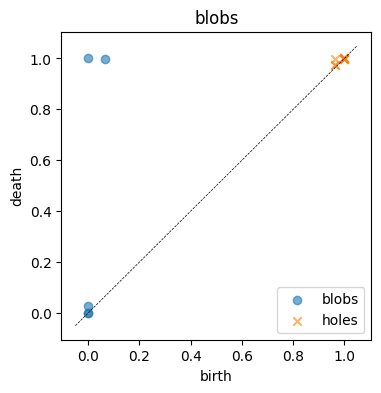


noise:  blobs(H0)=169  holes(H1)=199  max blob lifetime=0.39


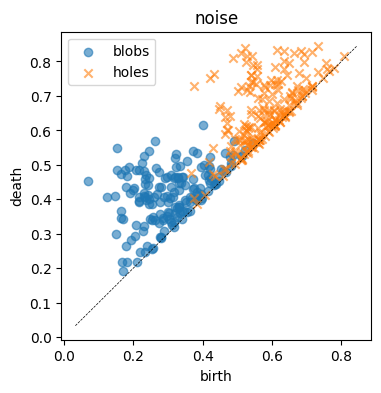

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(0)
noise = (rng.random((64, 64)) > 0.5).astype(float)
blob  = (gaussian_filter(noise, 4) > 0.5).astype(float)

for name, fld in [("blobs", blob), ("noise", noise)]:
    p = persistence(fld)
    print(f"\n{name}:  blobs(H0)={p['blobs_H0']['n_features']}  "
          f"holes(H1)={p['holes_H1']['n_features']}  "
          f"max blob lifetime={p['blobs_H0']['max_lifetime']:.2f}")

    # persistence diagram: points far from the diagonal = sturdy features
    plt.figure(figsize=(4,4))
    for dim, mk, lab in [("blobs_H0","o","blobs"), ("holes_H1","x","holes")]:
        pr = p[dim]["pairs"]
        if len(pr):
            plt.scatter(pr[:,0], pr[:,1], marker=mk, label=lab, alpha=0.6)
    lims = plt.xlim()
    plt.plot(lims, lims, "k--", lw=0.5)   # the diagonal
    plt.title(name); plt.xlabel("birth"); plt.ylabel("death"); plt.legend()
    plt.show()

Persistent homology findings.

First attempt was wrong  plain ripser treated the image as a set of points rather than flooding it, so the diagram was meaningless. Switched to gudhi which floods the image properly on its grid, and now it works.

The blobs image gives only 5 blobs and 10 holes, with a few points sitting right up in the top-left corner  born early, died late, so they survived nearly the whole flood. Those are the real sturdy structures.

The noise image gives 169 blobs and 199 holes, all crammed against the diagonal every feature born and dies almost instantly, max lifetime only 0.39 vs 1.0 for the blobs. So lots of features but none of them sturdy, which is exactly what noise is.

So the two useful numbers are the count of features and the lifetimes. This is the proper version of the Euler number instead of one count it tells me how many blobs and holes there are and how robust each one is.

Next is Minkowski, redone clean. It's three numbers that describe the shape of the white phase area (how much is white), perimeter (total boundary length), and the Euler number (blobs minus holes). There's a theorem that says these three are basically all the shape measures you need in 2D. It overlaps a bit with what I've already got, but it's the fast cheap three-number version, whereas persistent homology is the rich version. Redoing it properly this time with labelling I actually like.

In [57]:
import numpy as np

def minkowski(field):
    """
    The three 2D Minkowski functionals of the white phase (field == 1),
    computed periodically (wrap-around edges).
      area      = fraction of cells that are white
      perimeter = total boundary length between white and black
      euler     = number of blobs minus number of holes (8-connected)
    """
    f = (np.asarray(field) > 0).astype(int)
    ny, nx = f.shape

    # AREA: just the white fraction
    area = f.mean()

    # PERIMETER: count neighbour pairs (right + down, wrapped) that differ.
    # each such pair is one unit of boundary edge.
    right = f != np.roll(f, -1, axis=1)
    down  = f != np.roll(f, -1, axis=0)
    perimeter = (right.sum() + down.sum()) / (ny * nx)   # normalised per cell

    # EULER: 2x2 bit-quad estimator, 8-connected, periodic.
    # slide a 2x2 window over the (wrapped) grid and count corner patterns.
    a = f
    b = np.roll(f, -1, axis=1)
    c = np.roll(f, -1, axis=0)
    d = np.roll(np.roll(f, -1, axis=0), -1, axis=1)
    s = a + b + c + d                      # white corners in each 2x2 (0..4)

    q1 = np.sum(s == 1)                     # one white corner
    q3 = np.sum(s == 3)                     # three white corners
    # diagonal case: two white corners on a diagonal
    qd = np.sum((s == 2) & (a == d) & (b == c) & (a != b))
    euler = (q1 - q3 + 2 * qd) / 4.0

    return {"area": area, "perimeter": perimeter, "euler": euler}

In [58]:
import numpy as np
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(0)
noise = (rng.random((256, 256)) > 0.5).astype(int)
blob  = (gaussian_filter(noise.astype(float), 6) > 0.5).astype(int)

for name, fld in [("blobs", blob), ("noise", noise)]:
    m = minkowski(fld)
    print(f"{name:6s}: area={m['area']:.3f}  "
          f"perimeter={m['perimeter']:.3f}  euler={m['euler']:.1f}")

blobs : area=0.479  perimeter=0.077  euler=4.0
noise : area=0.499  perimeter=1.000  euler=4141.0


Minkowski findings.

Clean this time. Three numbers area, perimeter, Euler.

Area came out 0.479 vs 0.499, basically the same, because both images are half white. So area can't tell them apart on its own that's why you need the other two.

Perimeter was 0.077 for blobs vs 1.000 for noise. Big gap. The blobs only have boundary around a few smooth edges, whereas noise has a boundary between nearly every pixel, so it maxes out.

Euler was 4 for blobs vs 4141 for noise. This is the big one. Blobs are a handful of separate pieces, noise shatters into thousands of tiny specks. It's the same fragmentation signal as persistent homology but as one instant number, and it's the axis that caught my grown field breaking into loads of blobs before.

So the three together do the job area says same amount of white, perimeter says very different boundary length, Euler says a few blobs vs thousands of fragments.

Now the suite. This is the bit that ties it all together run it on an image and it gives back every descriptor's numbers in one go, which is what I wanted from the start. The catch is the four descriptors return different shapes a curve, a dict, lists, scalars — so the suite squeezes each one down to a few summary numbers and returns them all in one flat labelled list. That fixed list per image is also what PCA needs next.

In [59]:
import numpy as np

def _fourier_summary(field):
    freq, power = fourier_spectrum(field)
    freq, power = freq[1:], power[1:]                 # drop DC
    # characteristic scale: power-weighted mean frequency (the "blob size ruler")
    char_freq = np.sum(freq * power) / np.sum(power)
    # spectral slope: how fast power falls off (fit in log-log)
    mask = power > 0
    slope = np.polyfit(np.log(freq[mask]), np.log(power[mask]), 1)[0]
    return {"fourier_char_freq": char_freq, "fourier_slope": slope}

def _wavelet_summary(field):
    e = wavelet_energy(field)
    out = {}
    for lvl, vals in e.items():
        out[f"wave_{lvl}_total"] = vals["total"]
        # direction imbalance: how lopsided H/V/D are (0 = balanced, high = directional)
        hvd = np.array([vals["horizontal"], vals["vertical"], vals["diagonal"]], float)
        out[f"wave_{lvl}_imbalance"] = hvd.std() / (hvd.mean() + 1e-9)
    return out

def _persistence_summary(field):
    p = persistence(field)
    out = {}
    for name in ["blobs_H0", "holes_H1"]:
        out[f"pers_{name}_n"]   = p[name]["n_features"]
        out[f"pers_{name}_maxlife"] = p[name]["max_lifetime"]
    return out

def _minkowski_summary(field):
    m = minkowski(field)
    return {"mink_area": m["area"], "mink_perimeter": m["perimeter"],
            "mink_euler": m["euler"]}

def describe(field, verbose=True):
    """
    Run the whole descriptor suite on one field and return a single
    flat labelled dict of summary numbers. This is the fingerprint.
    """
    out = {}
    out.update(_fourier_summary(field))
    out.update(_wavelet_summary(field))
    out.update(_persistence_summary(field))
    out.update(_minkowski_summary(field))

    if verbose:
        print("descriptor suite:")
        for k, v in out.items():
            print(f"  {k:28s} {v:.4f}")
    return out

In [60]:
import numpy as np
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(0)
noise = (rng.random((128, 128)) > 0.5).astype(int)
blob  = (gaussian_filter(noise.astype(float), 6) > 0.5).astype(int)

print("=== BLOBS ==="); describe(blob)
print("\n=== NOISE ==="); describe(noise);



=== BLOBS ===


descriptor suite:
  fourier_char_freq            2.3290
  fourier_slope                -2.4040
  wave_level1_total            1095.7279
  wave_level1_imbalance        0.3989
  wave_level2_total            482.3330
  wave_level2_imbalance        0.4821
  wave_level3_total            224.6599
  wave_level3_imbalance        0.4143
  wave_level4_total            163.1629
  wave_level4_imbalance        0.2496
  pers_blobs_H0_n              6.0000
  pers_blobs_H0_maxlife        0.9992
  pers_holes_H1_n              7.0000
  pers_holes_H1_maxlife        1.0000
  mink_area                    0.5148
  mink_perimeter               0.0670
  mink_euler                   0.0000

=== NOISE ===
descriptor suite:
  fourier_char_freq            44.4548
  fourier_slope                -0.0524
  wave_level1_total            150.6261
  wave_level1_imbalance        0.2626
  wave_level2_total            271.8578
  wave_level2_imbalance        0.2339
  wave_level3_total            857.6701
  wave_level3_imbal

Last piece is PCA. The harness gives one row of numbers per image, so I stack a load of images into a table and PCA finds which descriptor axes actually carry the variation, and squashes each image down to 2 numbers so I can plot the whole set on one chart. Important bit: the columns are on totally different scales (euler goes to 1000, area is 0.5), so I standardise them all first, otherwise PCA just thinks the big-numbered columns matter most. This is the thing that turns five separate descriptors into one combined view.

In [61]:
import numpy as np

def build_table(fields):
    """Run describe() on each field, stack into a table.
    Returns (matrix [n_images x n_descriptors], column labels)."""
    rows, labels = [], None
    for f in fields:
        d = describe(f, verbose=False)
        if labels is None:
            labels = list(d.keys())
        rows.append([d[k] for k in labels])
    return np.array(rows, float), labels

def pca_suite(matrix, labels, n_components=2):
    """Standardise columns, run PCA, report variance explained and
    which descriptors load most strongly on each component."""
    X = matrix.copy()
    # standardise: each column to mean 0, spread 1
    mu, sd = X.mean(0), X.std(0)
    sd[sd == 0] = 1.0
    Xs = (X - mu) / sd

    # PCA via SVD
    U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
    var = S**2 / (len(Xs) - 1)
    var_ratio = var / var.sum()
    scores = U * S                      # each image's coords in PCA space

    print("variance explained:")
    for i in range(n_components):
        print(f"  PC{i+1}: {var_ratio[i]*100:5.1f}%")
        # which descriptors load most on this component
        loading = Vt[i]
        order = np.argsort(-np.abs(loading))[:4]
        for j in order:
            print(f"      {labels[j]:28s} {loading[j]:+.3f}")

    return scores[:, :n_components], var_ratio

variance explained:
  PC1:  81.4%
      mink_euler                   -0.269
      pers_blobs_H0_maxlife        +0.268
      fourier_char_freq            -0.268
      wave_level3_imbalance        +0.268
  PC2:  11.1%
      pers_holes_H1_maxlife        +0.583
      wave_level2_total            +0.489
      mink_area                    +0.466
      wave_level1_imbalance        -0.322


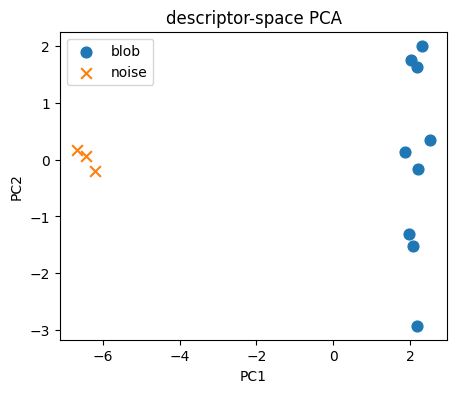

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(0)
fields, kinds = [], []
# blobs at a few different scales
for s in [4, 6, 8]:
    for seed in range(3):
        r = rng.random((128, 128))
        fields.append((gaussian_filter(r, s) > 0.5).astype(int)); kinds.append("blob")
# some pure noise
for seed in range(3):
    fields.append((rng.random((128, 128)) > 0.5).astype(int)); kinds.append("noise")

M, labels = build_table(fields)
scores, vr = pca_suite(M, labels)

plt.figure(figsize=(5,4))
for k, mk in [("blob","o"), ("noise","x")]:
    idx = [i for i,x in enumerate(kinds) if x==k]
    plt.scatter(scores[idx,0], scores[idx,1], marker=mk, label=k, s=60)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.title("descriptor-space PCA"); plt.show()

Now making the probability tables from the real sandstone. My old build_windows just learned a set of which patterns exist, which was fine for clean synthetic shapes. But on a big real rock nearly all 512 possible patterns show up, including rare noisy ones at the grain edges. So instead of just a set I want the counts — how often each pattern occurs — because that's the actual probability table, and it lets me see which patterns are common structure vs rare noise I might want to drop.

In [63]:
import gzip, numpy as np

# --- build the truth image from the raw Bentheimer volume ---
RAW = "Bentheimer_1000c_3p0035um.raw.gz"   # <-- check this matches your actual filename

with gzip.open(RAW, "rb") as fh:
    vol = np.frombuffer(fh.read(), dtype=np.uint8).reshape(1000, 1000, 1000)

sl = vol[500]                        # middle z-slice
crop = sl[128:128+512, 0:512]        # representative 512x512 window
truth = (crop == 0).astype(int)      # invert: pore -> 1 (foreground)

np.save("bentheimer_truth512.npy", truth)
print("truth shape:", truth.shape, " pore fraction:", truth.mean().round(4))

truth shape: (512, 512)  pore fraction: 0.2184


In [64]:
import os
print([f for f in os.listdir('.') if 'entheimer' in f])

['Bentheimer_1000c_3p0035um.mhd', 'Bentheimer_1000c_3p0035um.raw.gz', 'bentheimer_truth512.npy']


In [65]:
import numpy as np
from collections import Counter

def build_pattern_table(grid):
    """Every 3x3 pattern in the grid (periodic wrap), WITH counts.
    Returns a Counter {pattern_key: count}. The probability table.
    Same wrap convention as build_windows_periodic."""
    pad = np.pad(grid, 1, mode="wrap")
    rows, cols = grid.shape
    keys = np.empty((rows*cols, 9), dtype=np.int8)
    k = 0
    for dr in range(3):
        for dc in range(3):
            keys[:, k] = pad[dr:dr+rows, dc:dc+cols].ravel()
            k += 1
    return Counter(map(tuple, keys))

# learn the table from the real sandstone truth
table = build_pattern_table(truth)          # `truth` comes from the previous cell
total = sum(table.values())

print(f"grid {truth.shape}, {total} windows, pore fraction {truth.mean():.4f}")
print(f"distinct 3x3 patterns: {len(table)} of 512 possible\n")
print("top 10 patterns (count, fraction):")
for pat, cnt in table.most_common(10):
    print(f"  {pat}  {cnt:6d}  ({cnt/total:.4f})")

print()
for thr in [1, 2, 5, 10, 50]:
    rare = [c for c in table.values() if c <= thr]
    print(f"patterns <= {thr:2d} times: {len(rare):3d}   "
          f"carrying {sum(rare)/total*100:.3f}% of windows")

grid (512, 512), 262144 windows, pore fraction 0.2184
distinct 3x3 patterns: 345 of 512 possible

top 10 patterns (count, fraction):
  (np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0))  191161  (0.7292)
  (np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1))   44218  (0.1687)
  (np.int8(1), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0))    1004  (0.0038)
  (np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(1))     972  (0.0037)
  (np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(1), np.int8(0))     903  (0.0034)
  (np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int8(1), np.int8(0), np.int8(0))     898  (0.0034)
  (np.int8(0), np.int8(0), np.int8(1), np.int8(0), np.int8(0), np.int8(0), np.int8(0), np.int

We've made the pattern tables of the patterns we recognise. Now we're going to generate something like the image ourselves and apply the patterns to it. If something pops up that we don't recognise, we apply the hybrid method I talked about earlier to fix it  recognised windows we leave, otherwise flip the centre to try to make it legal, and if that still doesn't work fall back to the nearest legal pattern. Then we print the images side by side to see if it looks similar to the real thing. And we run the descriptor suite to check if they're statistically similar, not just similar to the eye.

Let's go back to what the method actually does well repair. I'll take the real sandstone, add a customisable amount of noise to it, then fix it with the hybrid approach (recognise and leave, else flip the centre, else nearest pattern) plus the speck cleanup. Then show the three side by side real, noisy, repaired — and see how much of the noise it clears. The key difference from generation is the real structure is still there underneath the noise, so the rule has something to lock onto.

noise added: 5%
pixels wrong:  5.0%  ->  0.9%


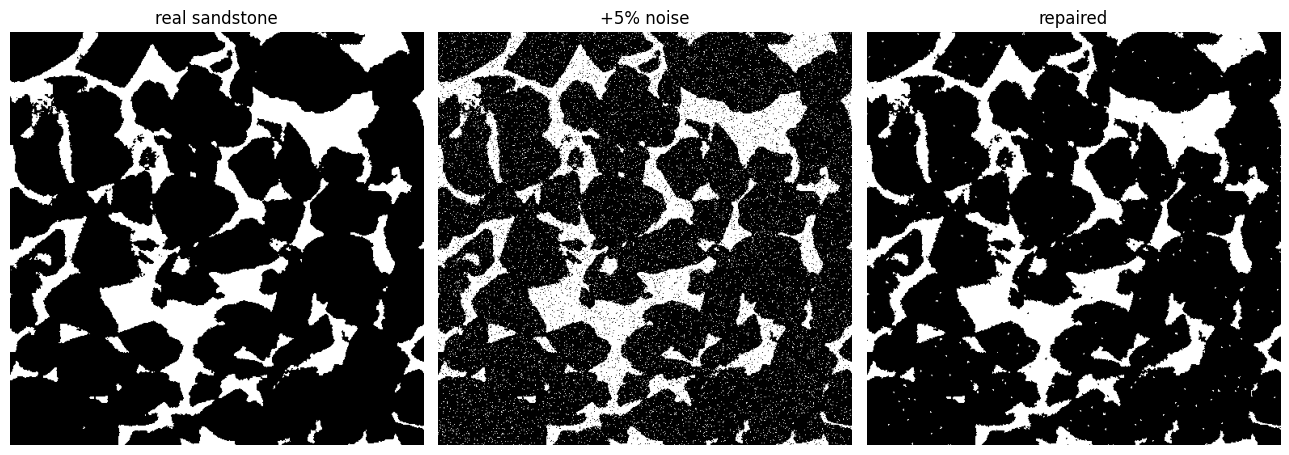

In [71]:
# === repair test: noise the real rock, fix with the hybrid rule ===
NOISE = 0.05       # <-- customisable: fraction of pixels to flip (try 0.05, 0.10, 0.25)
SEED  = 1
SWEEPS = 10

# learn the vocabulary from the real rock
seen = build_windows_periodic(truth)
PATTERNS = pattern_array(seen)

# add noise TO the real image (flip a random fraction of pixels)
rng = np.random.default_rng(SEED)
mask = rng.random(truth.shape) < NOISE
noisy = truth.copy()
noisy[mask] ^= 1

# repair with the hybrid rule + speck cleanup
repaired = run_sync(noisy, seen, PATTERNS, mode="hybrid", sweeps=SWEEPS, verbose=False)
repaired = clean_specks(repaired, thresh=7, rounds=3)

# how much noise did it clear?
wrong_before = (noisy != truth).mean()
wrong_after  = (repaired != truth).mean()
print(f"noise added: {NOISE:.0%}")
print(f"pixels wrong:  {wrong_before:.1%}  ->  {wrong_after:.1%}")

# show the three side by side
fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
for a, (t, img) in zip(ax, [("real sandstone", truth),
                            (f"+{NOISE:.0%} noise", noisy),
                            ("repaired", repaired)]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()